# Photoswitching fingerprints: modulating OFF probability

In [2]:
import os
import sys
import glob

path = os.path.abspath("")
splitted = path.split(os.sep)
user_independent = os.path.join(
    splitted[0] + os.sep, splitted[1], splitted[2], splitted[3]
)
src_path = os.path.join(user_independent, "GitHub", "Photoswitching")
sys.path.append(src_path)

import src.blinking as bl
import src.distributions as dist
import src.emissions as em
import src.fcs as fcs_p
import src.figure as fi
import src.fluorophores as fl
import src.formulas as fo
import src.miscellaneous as mi
import src.network as net
import src.simulation as si
import src.prediction as pr
import src.analysis as an
import src.transitions as tr
import src.routines as ro

import numpy as np
import pandas as pd

%load_ext autoreload
%autoreload 2

import warnings


def custom_warning_format(msg, category, filename, lineno, line=None):
    if line is None:
        import linecache

        line = linecache.getline(filename, lineno)
    return f"WARNING for line: {line} {msg} \n"


warnings.formatwarning = custom_warning_format

### Data preparation

In [2]:
fluorophores = fl.construct_fluorophores(
    name="cy5_dna", distance=3, count=1, shape="triangle"
)
fluorophore_system = fl.FluorophoreSystem(fluorophores=fluorophores)

irradiance=2.5
wavelength=640
bleaching=True
energy_transfer=True
reducing_agent="mea"
concentration=100
ph=7.5

In [3]:
transitions = fluorophore_system.load_transitions(
    irradiance=irradiance,
    wavelength=wavelength,
    bleaching=bleaching,
    energy_transfer=energy_transfer,
    dstorm=True,
    dstorm_parameters={'reducing_agent':reducing_agent,
    'concentration':concentration,
    'ph':ph},
)
transition_set = tr.TransitionSet(transitions, fluorophore_system)
transition_set = transition_set.adjust_rates({5:2e4, 4:1e7})
transition_set.finalize()

In [4]:
rng = np.random.default_rng(1)

In [13]:
transition_set = transition_set.adjust_rates({8:3e5, 9:3e6, 10:3e2, 11:3e3})
transition_set.finalize()
path = r"D:\simulation_data\off_prob"
fingerprint_red1, bl_times_red1 = ro.fingerprint_analysis(transition_set, batches=2, 
batch_size=450, filepath=path, filename='red1', seed=rng, use_memmap=r"C:\Users\vie43sq\Desktop\memmaps\run_4")

In [16]:
transition_set = transition_set.adjust_rates({8:3e4, 9:3e5, 10:3e1, 11:3e2})
transition_set.finalize()
path = r"D:\simulation_data\off_prob"
fingerprint_red01, bl_times_red01 = ro.fingerprint_analysis(transition_set, batches=2, 
batch_size=300, filepath=path, filename='red01', seed=rng, use_memmap=r"C:\Users\vie43sq\Desktop\memmaps\run_4")

In [15]:
transition_set = transition_set.adjust_rates({8:3e3, 9:3e4, 10:3e0, 11:3e1})
transition_set.finalize()
path = r"D:\simulation_data\off_prob"
fingerprint_red001, bl_times_red001 = ro.fingerprint_analysis(transition_set, batches=2, 
batch_size=450, filepath=path, filename='red001', seed=rng, use_memmap=r"C:\Users\vie43sq\Desktop\memmaps\run_4")

### Reading the data

In [3]:
identifiers = ['red001', 'red01', 'red1']
bleaching_times_all = []
fingerprints_all = []
fingerprints_discard = []

for _ in identifiers:
    fingerprints_all.append(pd.Series(np.zeros(300001), 
                                      np.round(np.linspace(0, 300, 300001), decimals=12), 
                                      dtype=np.int32))
    fingerprints_discard.append(pd.Series(np.zeros(299001), 
                                      np.round(np.linspace(1, 300, 299001), decimals=12), 
                                      dtype=np.int32))
folder_path = r"D:\simulation_data\off_prob"
for file in glob.glob(folder_path + "/*"):
    if file.endswith(".npy"):
        bleaching_times_all.append(np.load(file))
    elif file.endswith(".parquet"):
        for id in identifiers:
            if id in file:
                fingerprints_all[identifiers.index(id)] += pd.read_parquet(file).sum(axis=1)
                fingerprints_discard[identifiers.index(id)] += pd.read_parquet(file).iloc[1000:].sum(axis=1)
                break

for i, (fingerprint, fingerprint_discard) in enumerate(zip(fingerprints_all, fingerprints_discard)):
    fingerprint = fingerprint.cumsum() / fingerprint.sum()
    fingerprints_all[i] = fingerprint
    fingerprint_discard = fingerprint_discard.cumsum() / fingerprint_discard.sum()
    fingerprints_discard[i] = fingerprint_discard

### Fitting the data

##### Using the fingerprints and fitting a CDF

In [4]:
from lmfit import Model, Parameters

model = Model(dist.two_expon_mixture_cdf)
params = Parameters()
params.add('p', value=0.5, min=0, max=1)
params.add('lambda1', value=1, min=0)
params.add('lambda2', value=0.5, min=0)

parameters_all_fit_cdf = []
for fingerprint in fingerprints_all:
    result = model.fit(fingerprint, params, x=np.linspace(0, 300, 300001))
    parameters_all_fit_cdf.append([param.value for param in result.params.values()])

##### Using the bleaching times and fitting a PDF

In [34]:
parameters_all_fit_pdf = []
for bl_times in bleaching_times_all:
    pi, lambda1, lambda2 = dist.estimate_mixture_parameters(
        data=bl_times[:, 0][~np.isnan(bl_times[:, 0])],
        initial_guess=[0.5, 1, 1.1],
        bounds=([0, 1], [0, None], [0, None]),
        truncation_low=0,
        truncation_up=300,
        number_no_events=0,  # np.count_nonzero(np.isnan(bl_times[:, 0])),
        method='powell', 
    )
    parameters_all_fit_pdf.append([pi, lambda1, lambda2])

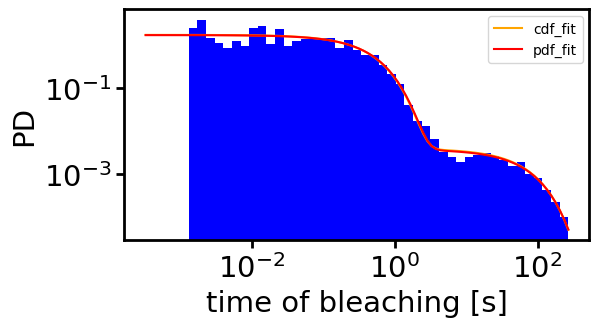

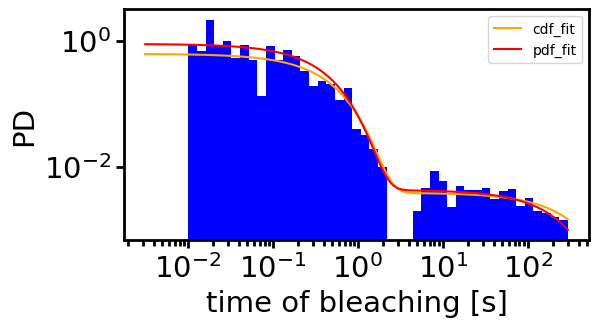

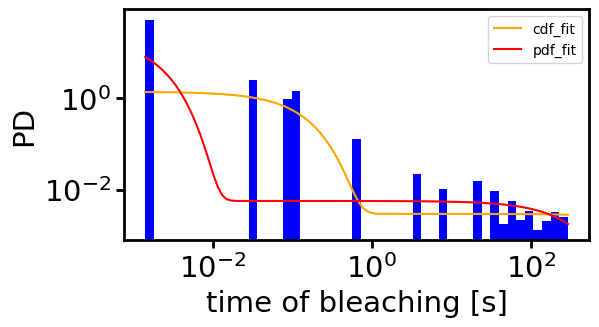

In [35]:
for (bl_times, parameters_1, parameters_2) in zip(bleaching_times_all, parameters_all_fit_pdf, parameters_all_fit_cdf):
    pi_fit_1, lambda1_fit_1, lambda2_fit_1 = parameters_1
    pi_fit_2, lambda1_fit_2, lambda2_fit_2 = parameters_2
    data = bl_times[:, 0][~np.isnan(bl_times[:, 0])]
    bins = np.logspace(np.log10(np.min(data)), np.log10(np.max(data)), 50)
    ax = fi.universal_figure(type_='hist', bins=bins, data=data, density=True) 
    x = np.logspace(np.log10(np.min(data)), np.log10(np.max(data)), 100)
    fi.universal_figure(data=[x, dist.two_expon_mixture_pdf(x, lambda1_fit_2, lambda2_fit_2, pi_fit_2)], 
                        axes=ax[0], color='orange', label='cdf_fit')
    fi.universal_figure(data=[x, dist.two_expon_mixture_pdf(x, lambda1_fit_1, lambda2_fit_1, pi_fit_1)], 
                        type_='line', axes=ax[0], yscale='log', xscale='log', 
                        xlabel='time of bleaching [s]', ylabel='PD', color='red', label='pdf_fit', legend=True)

array([[<Axes: title={'center': 'ON to OFF rate'}, xlabel='time (s)', ylabel='% emission'>]],
      dtype=object)

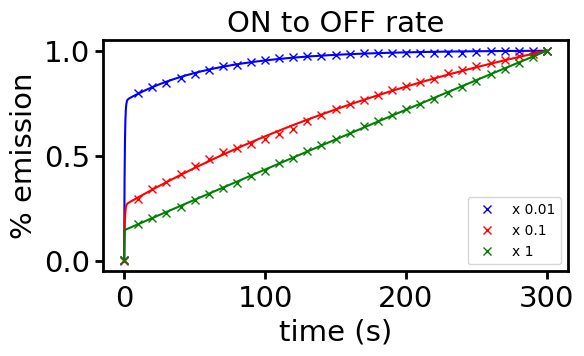

In [37]:
labels = ['x 0.01', 'x 0.1', 'x 1']
colors = ['b', 'r', 'g']
ax = None
x = np.linspace(0, 300, 1000)
for (fingerprint, parameters, label, color) in zip(fingerprints_all, parameters_all_fit_cdf, labels, colors):
    pi, lambda1, lambda2 = parameters
    if ax is None:
        ax = fi.universal_figure(data=[fingerprint.index[::10000], fingerprint[::10000]], label=label, color=color, marker='x', linestyle='')
    else:
        fi.universal_figure(data=[fingerprint.index[::10000], fingerprint[::10000]], axes=ax[0], label=label, color=color, marker='x', linestyle='')
    fi.universal_figure(data=[x, dist.two_expon_mixture_cdf(x, lambda1, lambda2, pi)], axes=ax[0], color=color)
fi.universal_figure(title='ON to OFF rate', ylabel='% emission', xlabel='time (s)', legend=True, axes=ax[0])

array([[<Axes: title={'center': 'ON to OFF rate'}, xlabel='time (s)', ylabel='% emission'>]],
      dtype=object)

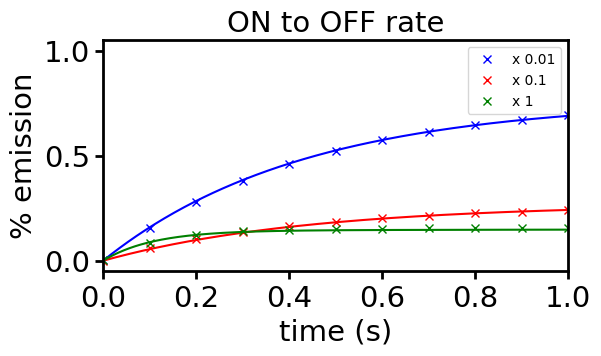

In [42]:
labels = ['x 0.01', 'x 0.1', 'x 1']
colors = ['b', 'r', 'g']
ax = None
x = np.linspace(0, 300, 100000)
for (fingerprint, parameters, label, color) in zip(fingerprints_all, parameters_all_fit_cdf, labels, colors):
    pi, lambda1, lambda2 = parameters
    if ax is None:
        ax = fi.universal_figure(data=[fingerprint.index[::100], fingerprint[::100]], label=label, color=color, marker='x', linestyle='')
    else:
        fi.universal_figure(data=[fingerprint.index[::100], fingerprint[::100]], axes=ax[0], label=label, color=color, marker='x', linestyle='')
    fi.universal_figure(data=[x, dist.two_expon_mixture_cdf(x, lambda1, lambda2, pi)], axes=ax[0], color=color)
fi.universal_figure(title='ON to OFF rate', ylabel='% emission', xlabel='time (s)', legend=True, axes=ax[0], xlim=[0, 1])

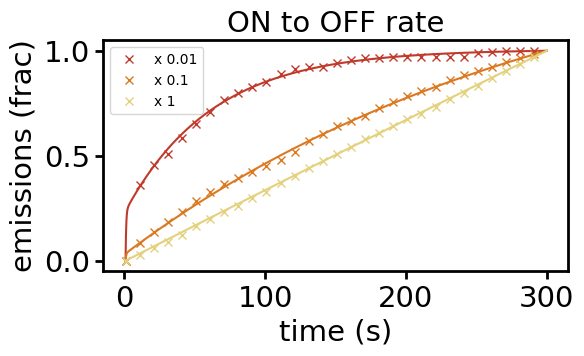

In [5]:
labels = ['x 0.01', 'x 0.1', 'x 1']
colors = ['#BF3A2B', '#DB7921', '#E4D17E']
ax = None
x = np.linspace(1, 300, 1000)
for (fingerprint, parameters, label, color) in zip(fingerprints_discard, parameters_all_fit_cdf, labels, colors):
    pi, lambda1, lambda2 = parameters
    if ax is None:
        ax = fi.universal_figure(data=[fingerprint.index[::10000], fingerprint[::10000]], label=label, color=color, marker='x', linestyle='')
    else:
        fi.universal_figure(data=[fingerprint.index[::10000], fingerprint[::10000]], axes=ax[0], label=label, color=color, marker='x', linestyle='')
    fi.universal_figure(data=[x, dist.two_expon_mixture_cdf(x, lambda1, lambda2, pi)], axes=ax[0], color=color)
fi.universal_figure(title='ON to OFF rate', ylabel='emissions (frac)', xlabel='time (s)', legend=True, axes=ax[0])
fig = mi.get_figure(ax)
fig.savefig("off_prob.svg")